# Task 2 — CNN Filter Visualization (CIFAR-10)

**Course:** Deep Learning I: Neural Networks — Final Project (Section 2, experimental)
**Group members (8):**  
| Name | Roll No | Email |  
|---|---|---|  
| Shreyansh Arora | 24BCS10252 | shreyansh.24bcs10252@sst.scaler.com |  
| Bhavya Patel | 24BCS10420 | bhavya.24bcs10420@sst.scaler.com |  
| Rudra Longaonkar | 24BCS10312 | rudra.24bcs10312@sst.scaler.com |  
| Mohammed Rehan | 24BCS10620 | mohammed.24bcs10620@sst.scaler.com |  
| Avishkar Chavan | 24BCS10065 | avishkar.24bcs10065@sst.scaler.com |  
| Milap Kothari | 24BCS10004 | milap.24bcs10004@sst.scaler.com |  
| Soham Ambore | 24BCS10258 | soham.24bcs10258@sst.scaler.com |  
| Shubh Shukla | 24BCS10093 | shubh.24bcs10093@sst.scaler.com |

## Goal
Train a small CNN on **CIFAR-10**, then look *inside* it:

1. Train + evaluate properly (loss/accuracy curves, **confusion matrix**).
2. Extract and plot the **first-layer convolution filters**.
3. Visualize **feature maps** at an **early** and a **late** layer for the same image.
4. Show how representations become **more abstract with depth**.

> Runs top-to-bottom on Google Colab. Use a **GPU** runtime (Runtime → Change
> runtime type → T4 GPU). Training ~12 epochs takes a couple of minutes on GPU.


## 1. Setup

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

# ---- Config ----------------------------------------------------------------
SEED   = 42
EPOCHS = 12
BATCH  = 128
LR     = 1e-3
# ---------------------------------------------------------------------------

torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('Using device:', device)

Using device: mps


## 2. Data — CIFAR-10

60,000 32x32 colour images in 10 classes. We use light augmentation (random crop
+ horizontal flip) on the training set and standard channel normalisation.

In [2]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
test_tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

train_set = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_tf)
test_set  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_tf)
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=0)

CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print('train', len(train_set), ' test', len(test_set))

train 50000  test 10000


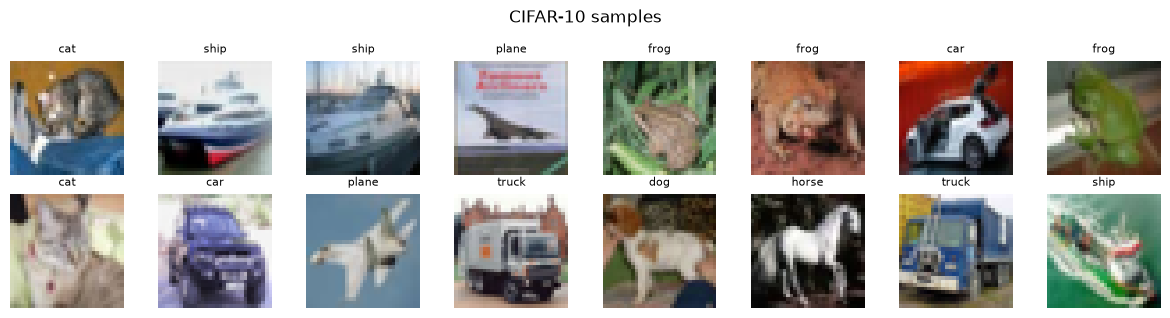

In [3]:
# De-normalise helper (for displaying images) and a quick sample grid.
mean_t = torch.tensor(MEAN).view(3,1,1)
std_t  = torch.tensor(STD).view(3,1,1)
def unnorm(img): return (img.cpu()*std_t + mean_t).clamp(0,1)

imgs, lbls = next(iter(test_loader))
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, im, lb in zip(axes.ravel(), imgs, lbls):
    ax.imshow(unnorm(im).permute(1,2,0).numpy()); ax.set_title(CLASSES[lb], fontsize=8); ax.axis('off')
plt.suptitle('CIFAR-10 samples'); plt.tight_layout(); plt.show()

## 3. Model — a small VGG-style CNN

Four conv layers with named attributes so we can attach hooks later.
- `conv1` (early): 32 filters at full 32x32 resolution — what we visualise as filters.
- `conv4` (late): 128 filters at 16x16 — the abstract, deep representation.

In [4]:
class SmallVGG(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   32,  3, padding=1)
        self.conv2 = nn.Conv2d(32,  64,  3, padding=1)
        self.conv3 = nn.Conv2d(64,  128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(128*8*8, 256)
        self.fc2   = nn.Linear(256, num_classes)
    def forward(self, x):
        x = F.relu(self.conv1(x))             # 32x32, 32ch   <- early
        x = self.pool(F.relu(self.conv2(x)))  # 16x16, 64ch
        x = F.relu(self.conv3(x))             # 16x16, 128ch
        x = self.pool(F.relu(self.conv4(x)))  # 8x8,   128ch  (conv4 out = 16x16 <- late)
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SmallVGG().to(device)
print(model)
print('params:', sum(p.numel() for p in model.parameters()))

SmallVGG(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
params: 2340810


## 4. Train

In [5]:
opt   = torch.optim.Adam(model.parameters(), lr=LR)
lossf = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(loader):
    model.eval(); correct = total = 0; loss_sum = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb); loss_sum += lossf(out, yb).item() * len(xb)
        correct += (out.argmax(1) == yb).sum().item(); total += len(xb)
    return loss_sum/total, correct/total

hist = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
for ep in range(EPOCHS):
    model.train(); correct = total = 0; loss_sum = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        out = model(xb); loss = lossf(out, yb)
        loss.backward(); opt.step()
        loss_sum += loss.item()*len(xb); correct += (out.argmax(1)==yb).sum().item(); total += len(xb)
    tr_loss, tr_acc = loss_sum/total, correct/total
    te_loss, te_acc = evaluate(test_loader)
    hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)
    hist['test_loss'].append(te_loss);  hist['test_acc'].append(te_acc)
    print(f"Epoch {ep+1:02d}/{EPOCHS}  train_loss {tr_loss:.3f} acc {tr_acc:.3f} | test_loss {te_loss:.3f} acc {te_acc:.3f}")

print(f"\nFinal test accuracy: {hist['test_acc'][-1]*100:.2f}%")

Epoch 01/12  train_loss 1.544 acc 0.433 | test_loss 1.114 acc 0.600


Epoch 02/12  train_loss 1.085 acc 0.609 | test_loss 0.867 acc 0.700


Epoch 03/12  train_loss 0.882 acc 0.687 | test_loss 0.765 acc 0.735


Epoch 04/12  train_loss 0.781 acc 0.724 | test_loss 0.681 acc 0.763


Epoch 05/12  train_loss 0.706 acc 0.752 | test_loss 0.633 acc 0.780


...

Epoch 08/12  train_loss 0.568 acc 0.800 | test_loss 0.567 acc 0.810


Epoch 09/12  train_loss 0.533 acc 0.814 | test_loss 0.545 acc 0.816


Epoch 10/12  train_loss 0.507 acc 0.823 | test_loss 0.542 acc 0.823


Epoch 11/12  train_loss 0.492 acc 0.828 | test_loss 0.526 acc 0.825


Epoch 12/12  train_loss 0.463 acc 0.839 | test_loss 0.499 acc 0.835

Final test accuracy: 83.47%


## 5. Evaluation — curves & confusion matrix

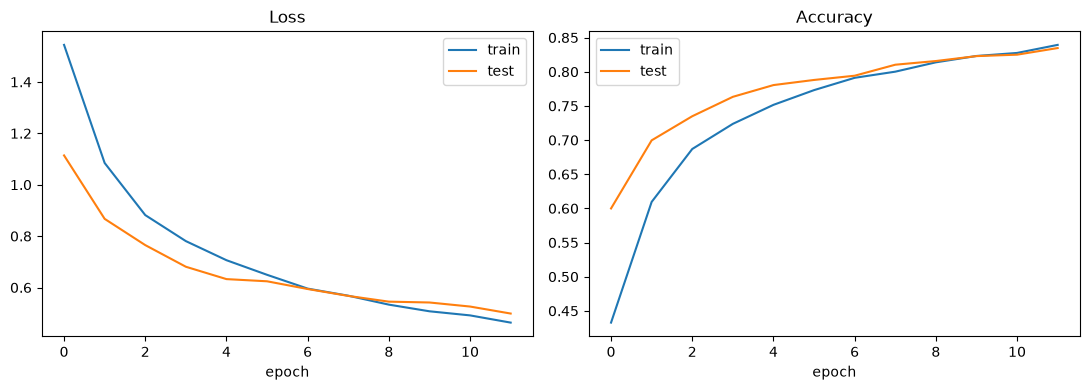

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist['train_loss'], label='train'); ax[0].plot(hist['test_loss'], label='test')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(hist['train_acc'], label='train'); ax[1].plot(hist['test_acc'], label='test')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

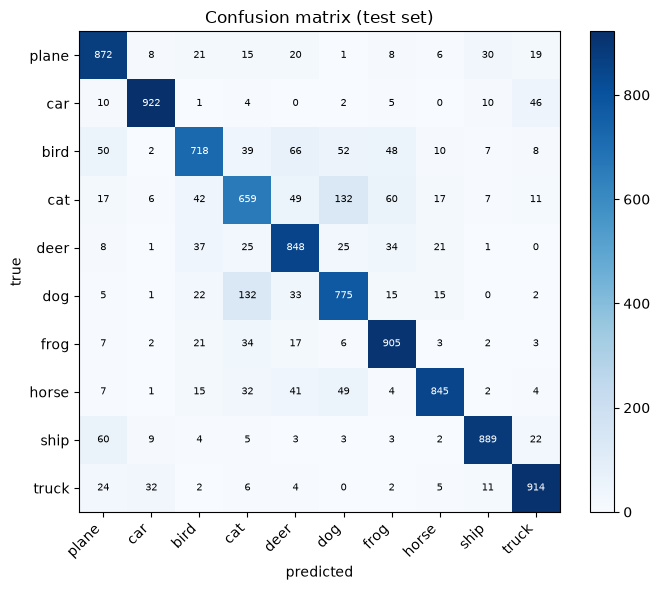

Per-class accuracy:
  plane   87.2%
  car     92.2%
  bird    71.8%
  cat     65.9%
  deer    84.8%
  dog     77.5%
  frog    90.5%
  horse   84.5%
  ship    88.9%
  truck   91.4%


In [7]:
# Confusion matrix (numpy, no extra deps).
@torch.no_grad()
def all_preds(loader):
    model.eval(); ys, ps = [], []
    for xb, yb in loader:
        ps.append(model(xb.to(device)).argmax(1).cpu().numpy()); ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(ps)

y_true, y_pred = all_preds(test_loader)
cm = np.zeros((10, 10), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES)
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title('Confusion matrix (test set)')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=7)
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

print('Per-class accuracy:')
for i, c in enumerate(CLASSES):
    print(f'  {c:6s} {cm[i,i]/cm[i].sum()*100:5.1f}%')

## 6. First-layer filters

The 32 filters of `conv1` are 3x3x3 (RGB). Each is normalised to [0,1] for
display. These are the *lowest-level* feature detectors — expect oriented edges,
colour-opponent blobs, and simple gradients.

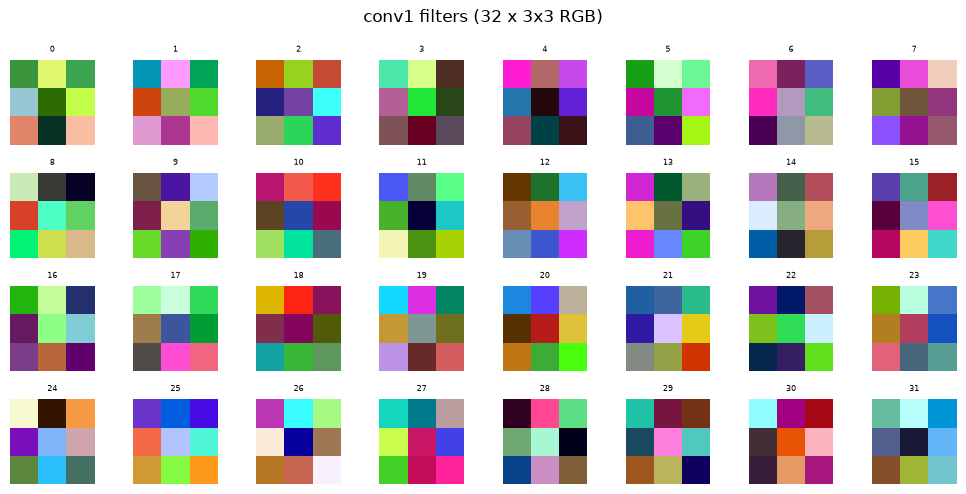

In [8]:
w = model.conv1.weight.data.clone().cpu()        # (32, 3, 3, 3)
w_min = w.amin(dim=(1,2,3), keepdim=True)
w_max = w.amax(dim=(1,2,3), keepdim=True)
w = (w - w_min) / (w_max - w_min + 1e-8)

fig, axes = plt.subplots(4, 8, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(w[i].permute(1, 2, 0).numpy()); ax.axis('off'); ax.set_title(f'{i}', fontsize=6)
plt.suptitle('conv1 filters (32 x 3x3 RGB)'); plt.tight_layout(); plt.show()

## 7. Feature maps — early vs late layer

We register **forward hooks** to capture the activations of `conv1` (early) and
`conv4` (late) for a single image, then plot the channel responses (post-ReLU).

input class: frog | early (32, 32, 32) | late (128, 16, 16)


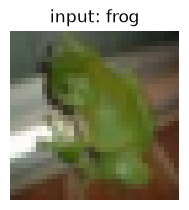

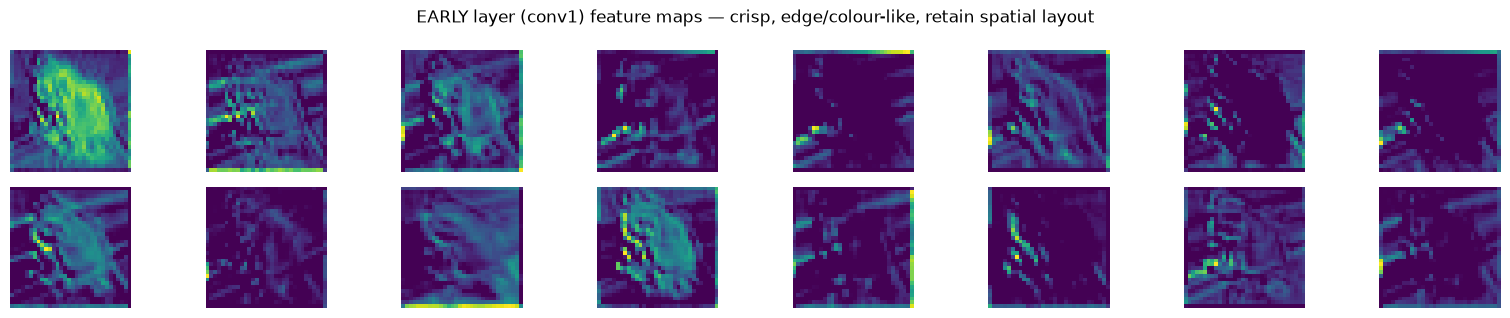

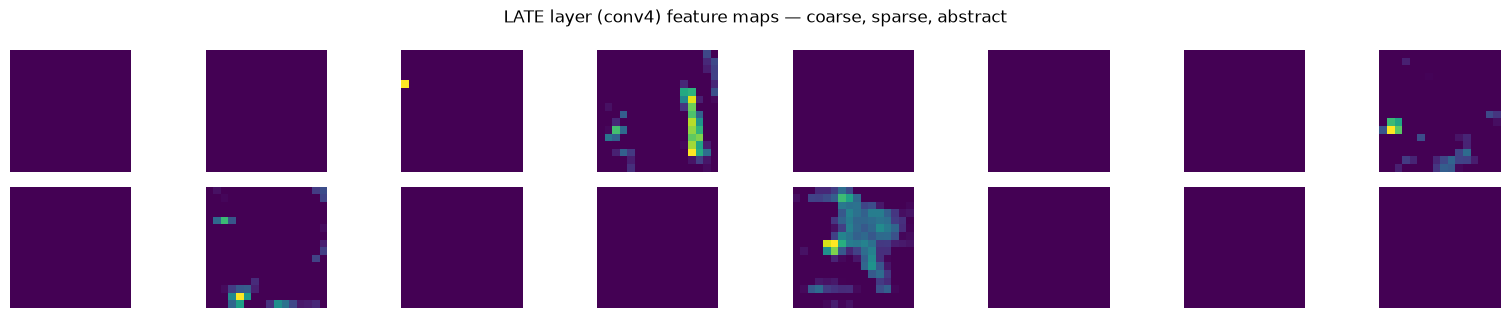

In [9]:
activations = {}
def hook(name):
    def fn(module, inp, out): activations[name] = out.detach()
    return fn

h1 = model.conv1.register_forward_hook(hook('early'))   # (1, 32, 32, 32)
h2 = model.conv4.register_forward_hook(hook('late'))    # (1, 128, 16, 16)

# Pick one test image and run a forward pass.
img, label = test_set[7]
model.eval()
with torch.no_grad():
    _ = model(img.unsqueeze(0).to(device))
h1.remove(); h2.remove()

early = torch.relu(activations['early'])[0].cpu()   # (32, 32, 32)
late  = torch.relu(activations['late'])[0].cpu()    # (128, 16, 16)
print('input class:', CLASSES[label], '| early', tuple(early.shape), '| late', tuple(late.shape))

def show_maps(maps, n, title):
    fig, axes = plt.subplots(2, n//2, figsize=(n, 3.2))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(maps[i].numpy(), cmap='viridis'); ax.axis('off')
    plt.suptitle(title); plt.tight_layout(); plt.show()

plt.figure(figsize=(2.2,2.2)); plt.imshow(unnorm(img).permute(1,2,0).numpy())
plt.title(f'input: {CLASSES[label]}'); plt.axis('off'); plt.show()
show_maps(early, 16, 'EARLY layer (conv1) feature maps — crisp, edge/colour-like, retain spatial layout')
show_maps(late, 16, 'LATE layer (conv4) feature maps — coarse, sparse, abstract')

## 8. Analysis — abstraction with depth

_Fill in referencing your own figures._

- **conv1 filters** look like classic low-level detectors: oriented edges and
  colour-opponent patches. They operate directly on RGB pixels.
- **Early feature maps (conv1)** are sharp and clearly preserve the object's
  outline — they respond to *where* edges and colours are. Different channels
  light up for different orientations/colours.
- **Late feature maps (conv4)** are low-resolution (16x16), **sparse**, and no
  longer look like the input. Each channel fires for an abstract pattern/part
  rather than a raw edge — the network has traded spatial detail for semantic
  content useful to the classifier.
- **Takeaway.** Depth builds a hierarchy: pixels → edges/colours → textures/parts
  → class-discriminative features. This is exactly why deep stacks of small
  convolutions work, and it is visible in the confusion matrix too — most errors
  fall between *semantically* similar classes (e.g. cat↔dog, car↔truck).
